In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy as cp


In [14]:
# load grid pph and outlook
forecast = xr.open_dataset('~/Downloads/grid_outlooks.nc')
verification = xr.open_dataset('data/storm_reports/grid_reports.nc')
pph = xr.open_dataset('data/pph/labelled_pph.nc')

day_str = 'all' # all, mdt, or slgt

In [15]:
forecast = forecast.sel(time = forecast['time'] >= '200203300000')
verification = verification.sel(time = verification['time'] >= '200203300000')
pph = pph.sel(time = pph['time'] >= '200203300000')

missing_dates = ['200204250000', '200208300000', '200304150000', '200304160000', '200306250000', '200307270000', '200307280000', '200312280000', '200404140000', '200408090000', '200905280000', '201105210000', '202005240000']
pph = pph.sel(time=~pph['time'].isin(missing_dates))
mdt_days = pph['time'][pph['MAX_CAT'].isin(['MDT', 'HIGH'])]
slgt_days = pph['time'][pph['MAX_CAT'].isin(['SLGT', 'ENH', 'MDT', 'HIGH'])]

if day_str == 'mdt':
    days = mdt_days
elif day_str == 'slgt':
    days = slgt_days
else:
    days = pph['time']

forecast = forecast.sel(time=forecast['time'].isin(days))
verification = verification.sel(time=verification['time'].isin(days))

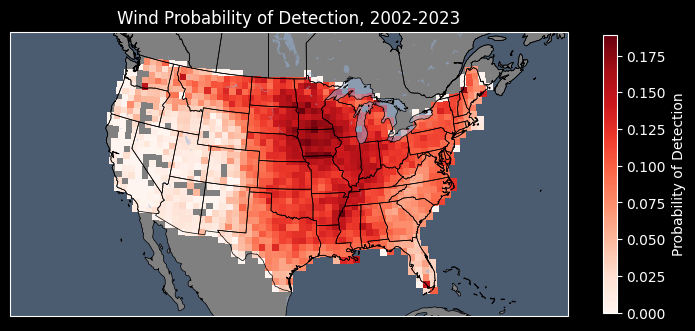

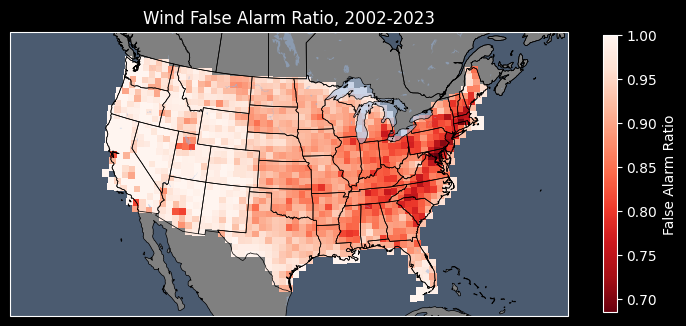

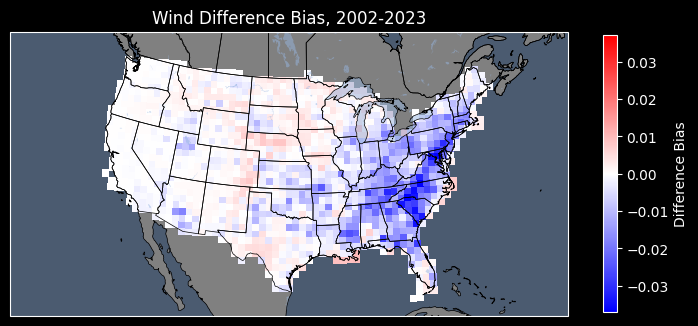

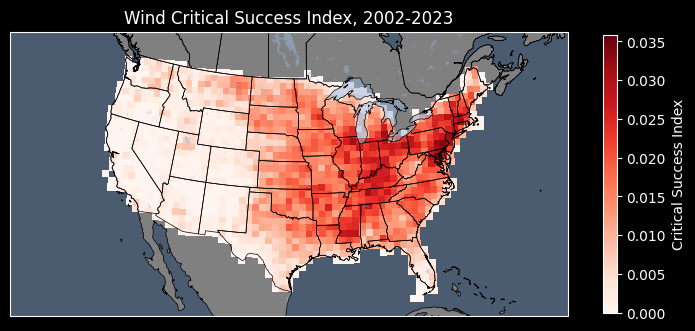

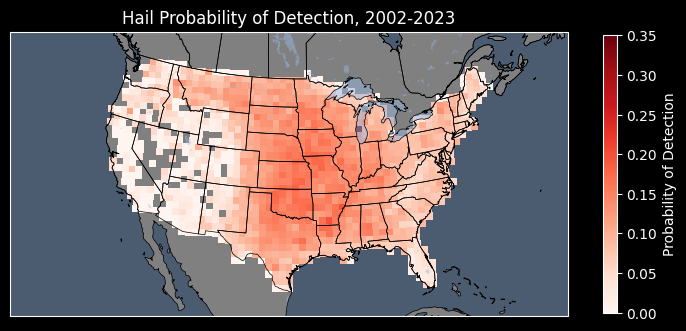

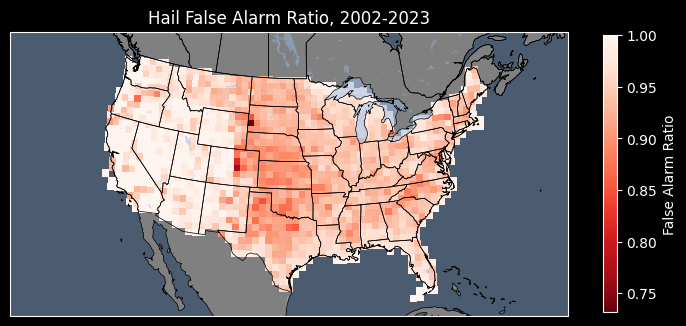

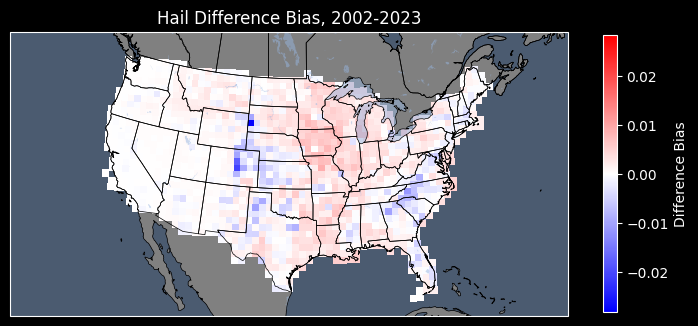

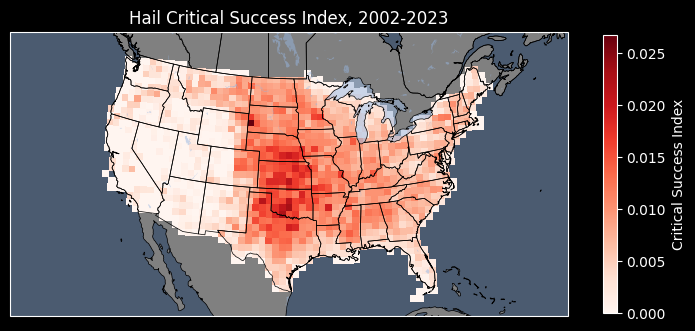

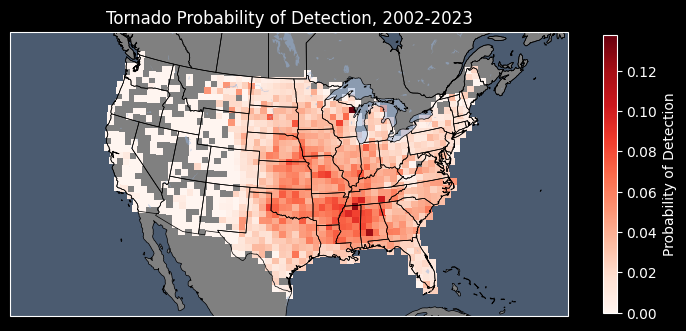

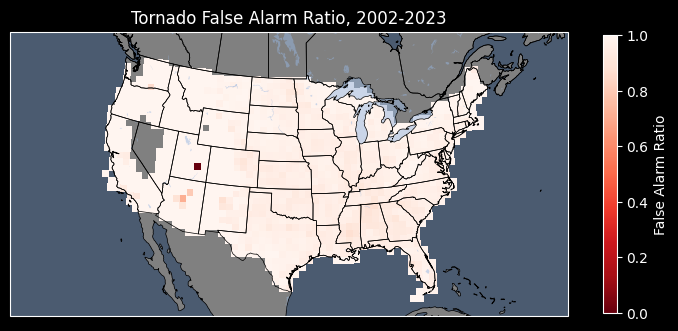

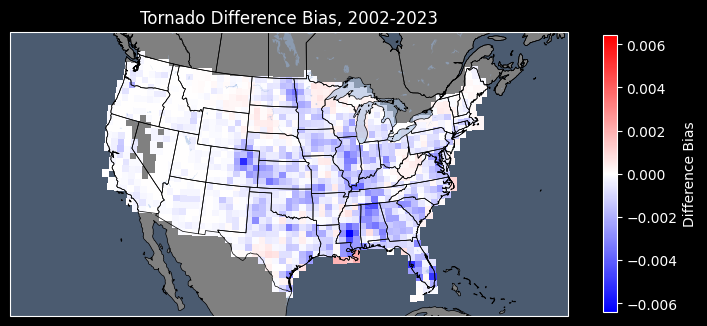

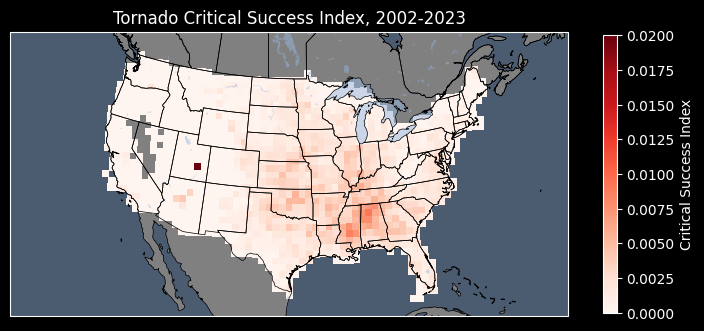

In [16]:
for hazard in ['Wind', 'Hail', 'Tornado']:
    f = forecast.sel(outlook = 'Day 1 ' + hazard)
    v = verification.sel(hazard = hazard)
    a = np.multiply(f['prob'], v['bool'])
    b = np.multiply(f['prob'], 1 - v['bool'])
    c = np.multiply(1 - f['prob'], v['bool'])
    d = np.multiply(1 - f['prob'], 1 - v['bool'])
    pod = (a/(a + c)).mean(dim = 'time')
    far = (b/(a+b)).mean(dim = 'time')
    bias = ((a + b) - (a + c)).mean(dim = 'time')
    csi = (a / (a + b + c)).mean(dim = 'time')
    plt.style.use("dark_background")

    for name, metric, cbar in zip(['Probability of Detection', 'False Alarm Ratio', 'Difference Bias', 'Critical Success Index'], [pod, far, bias, csi], ['Reds', 'Reds_r', 'bwr', 'Reds']):
        
        fig = plt.figure(figsize=(9,6))

        ax = plt.axes(projection=cp.crs.LambertConformal())

        # map background
        ax.add_feature(cp.feature.LAND, facecolor="grey")
        ax.add_feature(cp.feature.OCEAN, alpha=0.5)
        ax.add_feature(cp.feature.COASTLINE, linewidth=0.5)
        ax.add_feature(cp.feature.LAKES, alpha=0.5)
        ax.add_feature(cp.feature.STATES, linewidth=0.5)

        if name == 'Difference Bias':
            metric = metric.where(metric != 0)
            from matplotlib.colors import TwoSlopeNorm
            vv = np.nanmax(np.abs(metric.values))   # symmetric range
            norm = TwoSlopeNorm(vmin=-vv, vcenter=0, vmax=vv)

            # plot probabilities
            mesh = ax.pcolormesh(
                pph["lon"],
                pph["lat"],
                metric,
                transform=cp.crs.PlateCarree(),
                cmap=cbar,
                norm=norm
            )
        else:
            # plot probabilities
            mesh = ax.pcolormesh(
                pph["lon"],
                pph["lat"],
                metric,
                transform=cp.crs.PlateCarree(),
                cmap=cbar
            )

        cbar = plt.colorbar(mesh, ax=ax, shrink = .6)
        cbar.set_label(name)
        if day_str == 'mdt':
            plt.title(f"{hazard} {name} on MDT+ Risk Days, 2002-2023")
        elif day_str == 'slgt':
            plt.title(f"{hazard} {name} on SLGT+ Risk Days, 2002-2023")
        else:
            plt.title(f"{hazard} {name}, 2002-2023")

        ax.set_extent([-130, -65, 23, 50], crs=cp.crs.PlateCarree())

        plt.savefig(f"plots/contingency_maps/{hazard}_{name}_{day_str}.png", dpi=500, bbox_inches='tight')
        plt.show()